[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ofermend/hands-on-rag/blob/main/chapter2/parse-docx.ipynb)

# Chapter 2: Parsing DOCX Documents

In RAG pipelines, data comes in many formats — and Microsoft Word documents are among the most common in enterprise environments. Unlike plain text, DOCX files contain structured elements like paragraphs, tables, and embedded images that require specialized extraction.

This notebook demonstrates how to extract text, tables, and images from Word documents using python-docx.

**What you'll learn:**
- Extract paragraph text from DOCX files
- Parse table data into structured formats
- Extract embedded images from the DOCX archive

**Prerequisites:** `pip install python-docx Pillow`

## Setup and Text Extraction

We open a sample DOCX file with python-docx and iterate over its paragraphs and tables to extract structured text content.

In [4]:
"""Print the non-empty body paragraphs and the table rows of a .docx file."""

from typing import Final

import docx
from docx.document import Document as DocxDocument

# Resolved against the current working directory, not this file's location.
# The original notebook runs with the directory that contains sample_data/ as its CWD.
DOCX_FILE_PATH: Final[str] = "sample_data/sample_data.docx"
PARAGRAPH_SEPARATOR: Final[str] = "\n---\n"
TABLE_HEADER: Final[str] = "\n--- Table ---"


def print_non_empty_paragraphs(document: DocxDocument) -> None:
    """Print each top-level body paragraph that contains non-whitespace text.

    Paragraphs inside tables are not included here; print_tables covers them.
    """
    for paragraph in document.paragraphs:
        paragraph_text = paragraph.text
        # str.strip() with no argument removes all Unicode whitespace, including
        # non-breaking spaces, so a paragraph made only of those is skipped.
        stripped_paragraph_text = paragraph_text.strip()

        if len(stripped_paragraph_text) == 0:
            continue

        # The unstripped text is printed; stripping is only used for the emptiness test.
        print(paragraph_text, end=PARAGRAPH_SEPARATOR)


def print_tables(document: DocxDocument) -> None:
    """Print a header line for each top-level table, then one list of cell texts per row.

    python-docx's _Row.cells repeats a merged cell once for every grid column
    and row it spans, so merged text appears more than once.
    """
    for table in document.tables:
        print(TABLE_HEADER, end="\n")

        for row in table.rows:
            row_cell_texts = [cell.text for cell in row.cells]
            # print() would call str() on the list implicitly; the list-repr format is the intended output.
            row_cell_texts_repr = repr(row_cell_texts)
            print(row_cell_texts_repr, end="\n")


def main() -> None:
    # docx.Document is a factory function, not the Document class. Called with None
    # it silently returns a blank default-template document, so it always gets a path.
    # A missing or non-.docx file raises docx.opc.exceptions.PackageNotFoundError,
    # which is left to propagate: without the file there is nothing useful to do.
    document = docx.Document(DOCX_FILE_PATH)

    print_non_empty_paragraphs(document)
    print_tables(document)


if __name__ == "__main__":
    main()

Sample doc for RAG Book chapter 2
---
This is a great chapter 
---

--- Table ---
['Revision', 'Year']
['0.0.1', '2025']

--- Table ---
['Book', 'Revision', 'Year', 'Author']
['Memory and RAG', '0.1.0', '2026', 'A great researcher']
['RAG and AI', '0.0.1', '2025', 'A great researcher']


## Image Extraction

DOCX files are ZIP archives internally, so we can open them with `zipfile` and pull out embedded image files by their extension.

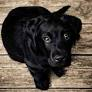

In [6]:
import zipfile

import os
from docx import Document
from IPython.display import display, Image

zipf = zipfile.ZipFile('sample_data/sample_data.docx')
filelist = zipf.namelist()
# print (filelist)

for fname in filelist:
  _, ext = os.path.splitext(fname)
  if ext in ['.jpg', '.jpeg', '.png', '.gif']:
    # read image and display in Jupyter
    with zipf.open(fname) as img_file:
        img_data = img_file.read()
        display(Image(data=img_data))